The simulation procedure for generating dependent, heavy-tailed functional densities is conducted in four primary stages, moving from the $L^2[0,1]$ Hilbert space back to the space of probability density functions.

The transformed functional process $\psi_t(u)$ is modeled as a combination of a static heavy-tailed template and a stochastic functional perturbation:
\begin{equation}
    \psi_t(u) = \psi_{\text{ref}}(u) + \sum_{k=1}^K \xi_{k,t} \phi_k(u)
\end{equation}
where:

* $\psi_{\text{ref}}(u) = \ln(Q'_{\text{ref}}(u))$ is the mLQDT of a Student-$t$ distribution with $\nu$ degrees of freedom.
* $\phi_k(u) = \sqrt{2} \cos(k \pi u)$ represents the orthonormal cosine basis functions.
* $\xi_{k,t}$ are temporal scores following independent AR(1) processes:
    \begin{equation}
        \xi_{k,t} = \varphi_k \xi_{k,t-1} + \varepsilon_{k,t}, \quad \varepsilon_{k,t} \sim N(0, \sigma_k^2)
    \end{equation}

To reconstruct the physical distribution, we first derive the Quantile Function $Q_t(u)$ by exponentiating the mLQDT curve and integrating over the domain $[0,1]$:
\begin{equation}
    Q_t(u) = \int_0^u \exp(\psi_t(s)) \, ds
\end{equation}

To ensure the resulting densities are centered at zero (consistent with financial return data), we calculate the time-varying mean $\mu_t$ and define the centered quantile function $Q_{t, \text{center}}(u)$:
\begin{align}
    \mu_t &= \int_0^1 Q_t(u) \, du \\
    Q_{t, \text{center}}(u) &= Q_t(u) - \mu_t
\end{align}

Finally, the observed density $f_t(x)$ is obtained through the inverse relationship of the quantile derivative:
\begin{equation}
    f_t(x) = \frac{1}{Q'_t(Q_{t, \text{center}}^{-1}(x))}
\end{equation}
where $Q_{t, \text{center}}^{-1}(x)$ denotes the cumulative distribution function (CDF) at time $t$.

In [6]:
import numpy as np 
import pandas as pd
from scipy.stats import norm, t
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt


import sys
sys.path.append("..")
from src.kde import verify_density_area
from src.transformations import (
                            dens2lqd,
                            lqd2dens,
                            mLQDT,
                            obtain_lqds,
                            obtain_densities_from_lqd,
                            modes_of_variation,
                            compute_lqd_cut
                            )

In [23]:
# Parameters
n = 1000  # sample size
df = 3    # degrees of freedom (lower = heavier tails)

# Simulation
samples_t = pd.Series(np.random.standard_t(df=df, size=n))
samples_t2 = pd.Series(np.random.standard_t(df=5, size=n))
samples_n = pd.Series(np.random.normal(loc=0, scale=1, size=n))

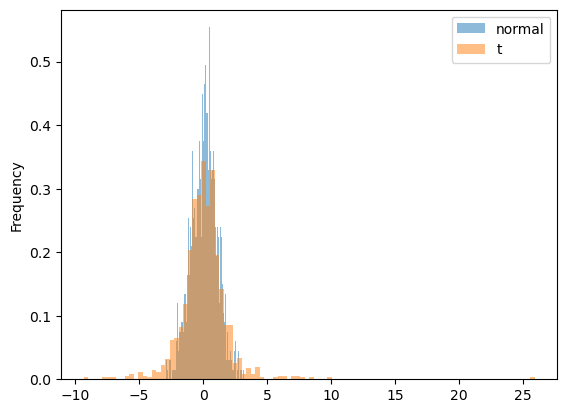

In [31]:
# samples_t2.plot(kind="hist", bins=100, density=True, label="t2", alpha=.5)
samples_n.plot(kind="hist", bins=100, density=True, label="normal", alpha=.5)
samples_t.plot(kind="hist", bins=100, density=True, label="t", alpha=.5)
plt.legend()

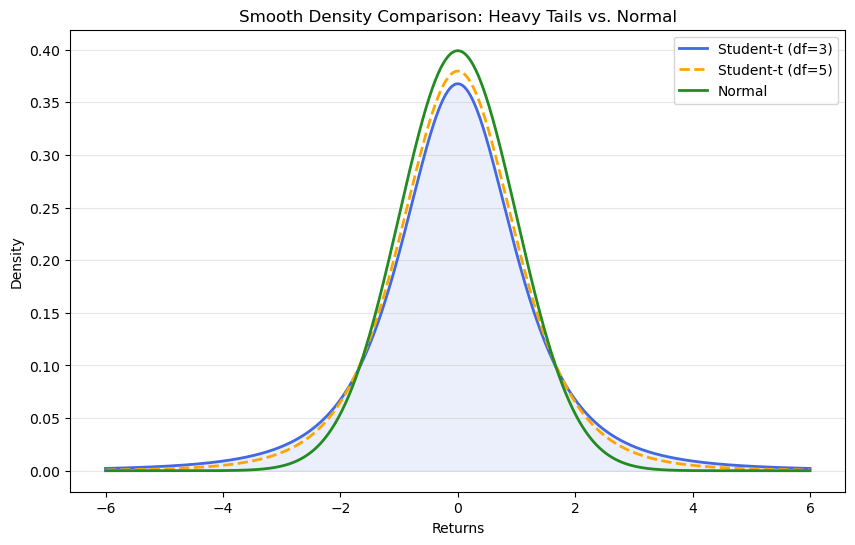

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# 1. Define a dense grid for the x-axis
# Using 1000 points makes the curve look perfectly smooth
x = np.linspace(-6, 6, 1000)

# 2. Calculate the "True" PDF values (not random samples)
pdf_t3 = t.pdf(x, df=3)
pdf_t5 = t.pdf(x, df=5)
pdf_normal = norm.pdf(x)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_t3, label="Student-t (df=3)", color="royalblue", lw=2)
plt.plot(x, pdf_t5, label="Student-t (df=5)", color="orange", lw=2, linestyle="--")
plt.plot(x, pdf_normal, label="Normal", color="forestgreen", lw=2)

plt.fill_between(x, pdf_t3, alpha=0.1, color="royalblue")
plt.title("Smooth Density Comparison: Heavy Tails vs. Normal")
plt.xlabel("Returns")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [8]:
verify_density_area(x,pdf_t3)

[Simpson] Total Area: 0.99072729


np.float64(0.9907272851067136)

In [11]:
lqd_support = np.linspace(0,1,5001)
lqdsup, lqd_t, c = dens2lqd(
                        dens = pdf_t3, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = 0,
                        verbose=True
                        )
lqdsup, lqd_n, c = dens2lqd(
                        dens = pdf_normal, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = 0,
                        verbose=True
                        )

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.
t0 is not a value in dSup - resetting to closest value
t0 is not a value in dSup - resetting to closest value


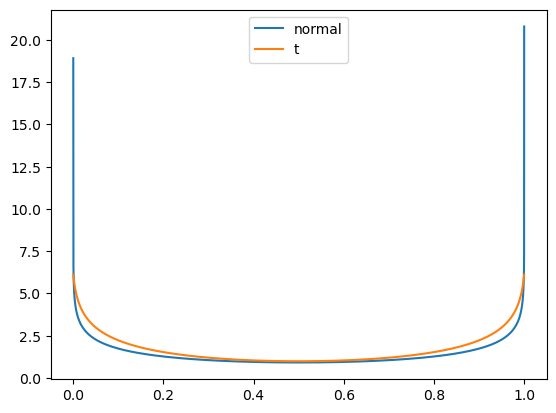

In [ ]:
plt.figure()

plt.plot(lqdsup, lqd_n, label="normal")
plt.plot(lqdsup, lqd_t, label="t")

plt.legend()
plt.show()

In [17]:
def simulate_dependent_densities(n_days, lqd_template, phis, sigma=0.1):
    """
    Simulates a sequence of LQD curves with temporal dependence.
    
    Args:
        n_days (int): Number of days to simulate.
        lqd_template (array): Your smooth T-distribution LQD (shape: nt,).
        phis (list): AR(1) coefficients for each 'flavor' of movement.
        sigma (float): Volatility of the daily changes.
    """
    nt = len(lqd_template)
    K = len(phis)
    u = np.linspace(0, 1, nt)
    
    # 1. Initialize the 'Scores' (How much of each cosine we use each day)
    # Shape: (K, n_days)
    scores = np.zeros((K, n_days))
    for k in range(K):
        # Daily shocks (Innovation)
        shocks = np.random.normal(scale=sigma, size=n_days)
        for t in range(1, n_days):
            scores[k, t] = phis[k] * scores[k, t-1] + shocks[t]
            
    # 2. Define the 'Shapes' (The basis functions)
    # We use sqrt(2)*cos to keep things orthonormal in L2
    basis = np.array([np.sqrt(2) * np.cos(np.pi * (k+1) * u) for k in range(K)])
    
    # 3. Combine: Template + (Scores * Basis)
    # We use matrix multiplication (@) for the 'perturbation' part
    perturbations = (scores.T @ basis).T # Result shape: (nt, n_days)
    
    # Add the template to every single day
    simulated_lqds = lqd_template[:, None] + perturbations
    
    return simulated_lqds, scores

# Example usage:
# lqd_t = your_array_from_t_sample
# phis = [0.8, -0.5] # Strong persistence in shape 1, oscillating shape 2
# curves, _ = simulate_dependent_densities(100, lqd_t, phis)

<Axes: >

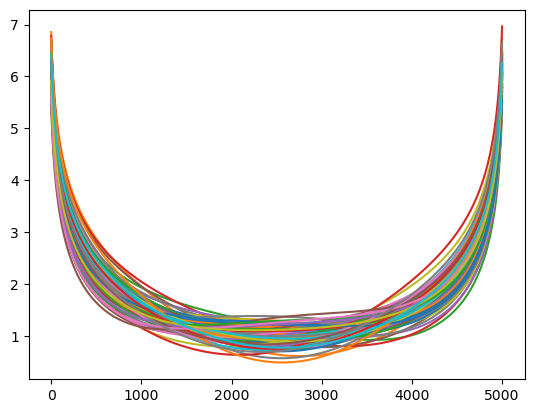

In [23]:
lqd_t = lqd
phis = [0.8, -0.5] # Strong persistence in shape 1, oscillating shape 2
curves, _ = simulate_dependent_densities(100, lqd_t, phis)
df_lqds = pd.DataFrame(curves)
df_lqds.plot(legend=False)

In [25]:
kle_bkw_supports, kle_bkw_densities = obtain_densities_from_lqd(
                                                            df_lqds,
                                                            lqd_support,
                                                            c_=[0 for i in range(df_lqds.shape[1])],
                                                            t_=[0 for i in range(df_lqds.shape[1])],
                                                            verbose=False
                                                            )

In [29]:
kle_bkw_supports

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.002400,0.002234,0.002900,0.002497,0.002397,0.002625,0.002283,0.002127,0.002773,0.002174,...,0.002030,0.003549,0.001984,0.002866,0.002076,0.002703,0.002055,0.003041,0.002204,0.002822
2,0.004800,0.004469,0.005800,0.004995,0.004794,0.005250,0.004566,0.004254,0.005547,0.004349,...,0.004059,0.007098,0.003967,0.005732,0.004153,0.005405,0.004110,0.006082,0.004407,0.005643
3,0.007201,0.006703,0.008700,0.007492,0.007191,0.007875,0.006850,0.006381,0.008320,0.006523,...,0.006089,0.010647,0.005951,0.008598,0.006229,0.008108,0.006165,0.009123,0.006611,0.008465
4,0.009601,0.008937,0.011601,0.009990,0.009588,0.010500,0.009133,0.008507,0.011093,0.008698,...,0.008119,0.014195,0.007935,0.011464,0.008306,0.010810,0.008220,0.012164,0.008814,0.011286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,11.991480,11.162366,14.489039,12.477203,11.975674,13.114252,11.407055,10.625802,13.855741,10.863722,...,10.140122,17.730114,9.910338,14.318287,10.373798,13.502057,10.267007,15.193127,11.009262,14.096814
4997,11.993880,11.164600,14.491939,12.479701,11.978071,13.116877,11.409338,10.627929,13.858514,10.865896,...,10.142152,17.733663,9.912321,14.321153,10.375875,13.504760,10.269062,15.196168,11.011466,14.099636
4998,11.996280,11.166834,14.494839,12.482198,11.980468,13.119502,11.411621,10.630056,13.861287,10.868071,...,10.144182,17.737212,9.914305,14.324019,10.377951,13.507462,10.271117,15.199209,11.013670,14.102457
4999,11.998680,11.169069,14.497739,12.484696,11.982865,13.122127,11.413905,10.632183,13.864061,10.870245,...,10.146211,17.740761,9.916289,14.326885,10.380028,13.510165,10.273172,15.202250,11.015873,14.105279


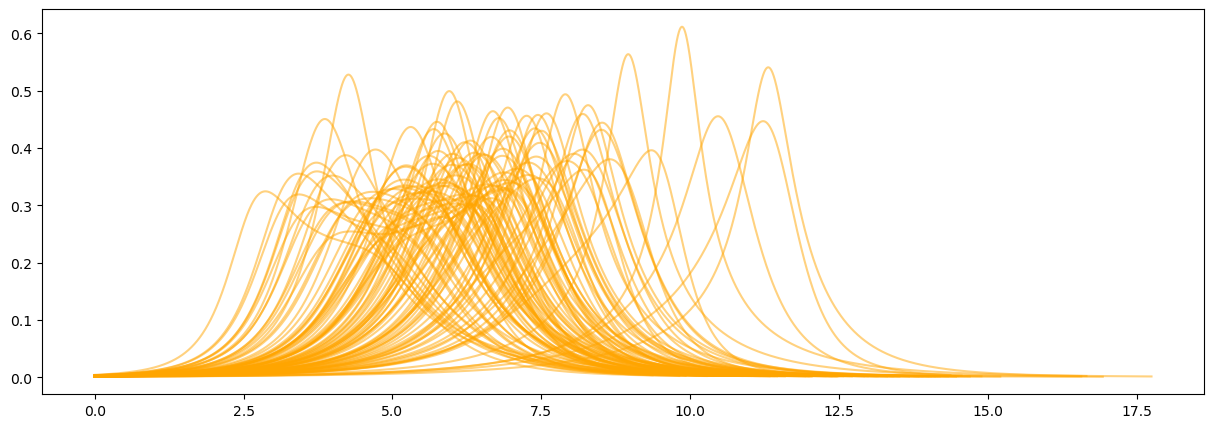

In [28]:
plt.figure(figsize=(15,5))
for i in range(kle_bkw_densities.shape[1]):
    plt.plot(kle_bkw_supports.iloc[:,i], kle_bkw_densities.iloc[:,i], c="orange", alpha=.5)
plt.show()